# Multiple Linear Regression

*Leandro Mineti*

*Last edit: March 2020*

## Introduction

We want to model a linear relation between the features $X$ and a scalar target variable $y$. Before diving into the math, if you want to get an intuition on how linear regression works, check out [Luis Serrano's explanation](https://www.youtube.com/watch?v=wYPUhge9w5c) [1]. Other interesting references are the [Homemade 
Machine Learning](https://github.com/trekhleb/homemade-machine-learning/tree/master/homemade/linear_regression) [2] and [Machine Learning Basics](https://github.com/zotroneneis/machine_learning_basics/blob/master/linear_regression.ipynb) [3].


In [0]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(51)  # Set seed for reproducibility

# Parameters
real_mean = [1, 3, 5]
real_cov = np.matrix([[4, 1, 2], [1, 9, -4], [2, -4, 21]])

# Sample size
n = 100

# Generate data
data = np.random.multivariate_normal(mean = real_mean, cov = real_cov, size = n)

## Multiple linear regression

Generalizing the definition of the [simple linear regression](https://colab.research.google.com/drive/1NUtc-TWBTe2XVD2xdkjwPD4sc43Ozf0g), suppose we have a vector of $k$ features, $\mathbf{x} = [x_1, x_2, ..., x_k]$, the model of $Y$ given $\mathbf{x}$ is:

$$y_i = \beta_0 + \beta_1 x_{1i} + \beta_2 x_{2i} +  \ldots + \beta_k x_{ki} + \epsilon_i$$

We can have a more compact representation using matrix notation:

$$
\mathbf{Y}=\left[\begin{array}{r}
                    y_1\\
                    \vdots\\
                    y_n
                  \end{array}\right], \quad
\mathbf{X}=\left[\begin{array}{cccc}
                    1&x_{11}&\ldots&x_{1k}\\
                    \vdots&\vdots&\ddots&\vdots\\
                    1&x_{n1}&\ldots&x_{nk}\end{array}\right],\quad
\boldsymbol{\beta}  =\left[\begin{array}{r}
                      \beta _0\\
                      \beta _1\\
                      \vdots\\
                      \beta _k\\
              \end{array}\right],\quad
\boldsymbol{\epsilon} =\left[\begin{array}{r}
                        \epsilon_1\\
                        \vdots\\
                        \epsilon_n\\
                      \end{array}\right]
$$

Than, the multiple regression model can be defined as $\mathbf{Y}= \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\epsilon}$. For a sample of size $n$ and $k$ features we have a vector $\mathbf{Y}_{n \times 1}$, a matrix $\mathbf{X}_{n \times p}$, where $p=k+1$, the vector of parameters $\boldsymbol{\beta}_{p \times 1}$ and the vector of random errors $\boldsymbol{\epsilon}_{n \times 1}$. Besides, we have that 
$E(\boldsymbol{\epsilon})=\mathbf{0}$ and $Cov(\boldsymbol{\epsilon})=\sigma^2\mathbf{I}$, onde $\mathbf{I}_{n \times n}$ is the identity matrix.
                 

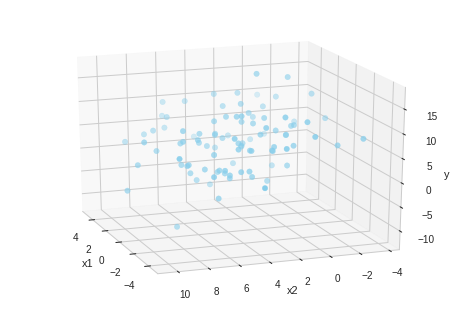

In [0]:
# Plot data
sns.set_style("whitegrid")
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data[:,0], data[:,1], data[:,2], c='skyblue', s=30)
ax.view_init(20, 160)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('y')
plt.show()

### Parameter estimation

First, let's write the residual sum of squares in matrix notation:

$$RSS(\boldsymbol{\beta})=(\mathbf{Y}-\mathbf{X}\boldsymbol{\beta})^T(\mathbf{Y}-\mathbf{X}\boldsymbol{\beta})$$

In order to estimate the parameters $\beta$, we can use the least square estimator:

$$\hat{\boldsymbol{\beta}}= \underset{\boldsymbol{\beta}}{argmin} (\mathbf{Y}-\mathbf{X}\boldsymbol{\beta})^T(\mathbf{Y}-\mathbf{X}\boldsymbol{\beta})$$

We can derive a closed form for the estimator calculating the derivative with respect to the parameters and setting it equal to 0:

$$
\begin{align}
\frac{\partial RSS}{\partial \boldsymbol{\beta}} &= -2 \mathbf{X}^T (\mathbf{Y}-\mathbf{X}\hat{\boldsymbol{\beta}}) \\
\frac{\partial RSS}{\partial \boldsymbol{\beta}} &= -2 \mathbf{X}^T\mathbf{Y}+2\mathbf{X}^T\mathbf{X}\hat{\boldsymbol{\beta}} = 0
\end{align}
$$

solving for $\hat{\boldsymbol{\beta}}$ we have:

$$\mathbf{X}^T\mathbf{X}\hat{\boldsymbol{\beta}} = \mathbf{X}^T\mathbf{Y}$$

$$\hat{\boldsymbol{\beta}} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{Y}$$

In [0]:
# Set simple estimator
X = np.c_[np.repeat(1, n), data[:,:2]]
Y = data[:,2]

beta_hat = np.linalg.inv(np.transpose(X)@X)@np.transpose(X)@Y

'The estimated coefficients beta_0, beta_1 and beta_2 are {}, {} and {}, respectively'.format(np.round(beta_hat[0], 3), np.round(beta_hat[1], 3), np.round(beta_hat[2], 3))

'The estimated coefficients beta_0, beta_1 and beta_2 are 6.546, 0.66 and -0.766, respectively'

We can achieve the same result by optimizing the cost function directly.

In [0]:
# Cost function for the ordinal least squares
def rss(beta, x, y):
  return (np.transpose(Y - X@beta)@(Y - X@beta))

beta_optim = minimize(rss, [0, 0, 0], args = (X,Y)).x

'The estimated coefficients beta_0, beta_1 and beta_2 are {}, {} and {}, respectively'.format(np.round(beta_optim[0], 3), np.round(beta_optim[1], 3), np.round(beta_optim[2], 3))

'The estimated coefficients beta_0, beta_1 and beta_2 are 6.546, 0.66 and -0.766, respectively'

Let's take a look at the model we just created.

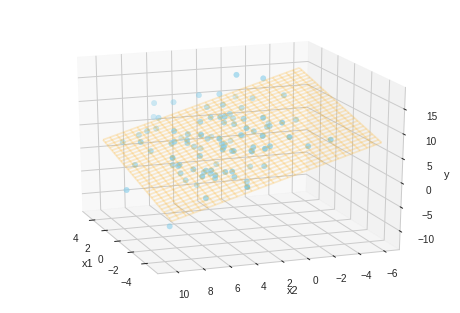

In [0]:
x_plot, y_plot = np.meshgrid(np.linspace(-5, 5, 30), np.linspace(-6, 10, 30))

y_hat_grid = beta_hat[0] + beta_hat[1]*x_plot + beta_hat[2]*y_plot

# Plot data
sns.set_style("whitegrid")
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data[:,0], data[:,1], data[:,2], c = 'skyblue', s=30)
ax.plot_wireframe(x_plot, y_plot, Z = y_hat_grid, color = 'orange', alpha=0.2)
ax.view_init(20, 160)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('y')
plt.show()

### Properties of the estimators

As $\boldsymbol{\beta}$ is a vector of random variables, we can assess its expected value and variance. First, let's check the expected value:

$$
\begin{align}
E(\hat{\boldsymbol{\beta})} &= E[(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{Y}] \\
E(\hat{\boldsymbol{\beta})} &= E[(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T(\mathbf{X}\boldsymbol{\beta} + \boldsymbol{\epsilon})] \\
E(\hat{\boldsymbol{\beta})}  &=E[(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{X}\boldsymbol{\beta} + (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\boldsymbol{\epsilon}]\\
E(\hat{\boldsymbol{\beta})} & = \boldsymbol{\beta} + (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^TE(\boldsymbol{\epsilon}) \\
E(\hat{\boldsymbol{\beta})} & = \boldsymbol{\beta} \\
\end{align}
$$

For the (co)variance, we have:

$$
\begin{align}
Cov(\hat{\beta}) &= Cov\left[ (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{Y} \right] \\
Cov(\hat{\beta}) &= (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T Cov(\mathbf{Y})\mathbf{X}(\mathbf{X}^T\mathbf{X})^{-1} \\ 
Cov(\hat{\beta}) &= (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T Cov(\varepsilon)\mathbf{X}(\mathbf{X}^T\mathbf{X})^{-1} \\
Cov(\hat{\beta}) &= (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T \sigma^2 \mathbf{I}\mathbf{X}(\mathbf{X}^T\mathbf{X})^{-1} \\ 
Cov(\hat{\beta}) &= \sigma^2(\mathbf{X}^T\mathbf{X})^{-1}
\end{align}
$$

As an example, for our regression case:

$$ \sigma^2(\mathbf{X}^T\mathbf{X})^{-1} =
       \begin{bmatrix}
          Var(\hat{\beta}_0)&Cov(\hat{\beta}_0,\hat{\beta}_1)&Cov(\hat{\beta}_0,\hat{\beta}_2)\\
          Cov(\hat{\beta}_1,\hat{\beta}_0)&Var(\hat{\beta}_1)&Cov(\hat{\beta}_1,\hat{\beta}_2) \\
          Cov(\hat{\beta}_2,\hat{\beta}_0)&Cov(\hat{\beta}_2,\hat{\beta}_1)&Var(\hat{\beta}_2) 
       \end{bmatrix} $$

In practice, we usually do not have access to the real value of $\sigma^2$. In that case, we can substitute it for the estimator $\sigma^2$ is $\hat{\sigma^2} = \frac{\sum_{i=1}^{n}{(y_i - \hat{y})^2}}{n-p}$ where $p$ is the number of estimated parameters. Let's take a look at the covariance matrix of the estimators.


In [0]:
#Estimating the variance of the estimators
cov_hat = real_cov[2,2]*np.linalg.inv(np.transpose(X)@X)

cov_hat

array([[ 0.49623002, -0.02224902, -0.08160554],
       [-0.02224902,  0.06154692, -0.00667386],
       [-0.08160554, -0.00667386,  0.02609885]])

In order to assess the results, let's derive the real $\boldsymbol{\beta}$s from the vector of means and covariance matrix we used to generate the data [4].

In [0]:
# Get real coefficients
a = real_cov[0:2, 0:2]
b = real_cov[0:2, 2]

real_betas = np.linalg.solve(a, b)

real_beta_0 = real_mean[2] - real_mean[0:2]*real_betas

'The real values for beta_0, beta_1 and beta_2 are {}, {}, {}, respectively.'.format(np.round(real_beta_0, 5), np.round(real_betas[0], 5), np.round(real_betas[1], 5))

'The real values for beta_0, beta_1 and beta_2 are [[5.91429]], [[0.62857]], [[-0.51429]], respectively.'

 We can compare the expected coefficient distributions with the estimated coefficients by generating a hundred samples with n = 100 and assessing the results. 

In [0]:
np.random.seed(51)

# Generate data
data_100 = np.random.multivariate_normal(mean = real_mean, cov = real_cov, size = (100, n))

# Estimators
beta_100 = np.array([np.linalg.inv(np.transpose(np.c_[np.repeat(1, n), i[:,:2]])@np.c_[np.repeat(1, n), i[:,:2]])@np.transpose(np.c_[np.repeat(1, n), i[:,:2]])@i[:, 2] for i in data_100])

#### Distribution for $\beta_0$

/usr/local/lib/python3.6/dist-packages/matplotlib/axes/_axes.py:6521: MatplotlibDeprecationWarning: 
The 'normed' kwarg was deprecated in Matplotlib 2.1 and will be removed in 3.1. Use 'density' instead.
  alternative="'density'", removal="3.1")


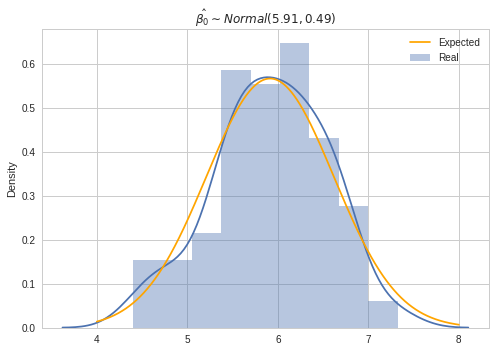

In [0]:
exp_x = np.array(np.linspace(4,8,1000))
exp_b0 = norm.pdf(exp_x, loc = real_beta_0, scale = np.sqrt(cov_hat[0,0]))  

sns.distplot(beta_100[:,0], norm_hist = True)
plt.plot(exp_x, np.transpose(exp_b0), color = 'orange')
plt.ylabel('Density')
plt.legend(('Expected', 'Real'), loc='upper right')
plt.title(r"$\hat{\beta_0} \sim Normal (5.91, 0.49)$")
plt.show();

#### Distribution for $\beta_1$

/usr/local/lib/python3.6/dist-packages/matplotlib/axes/_axes.py:6521: MatplotlibDeprecationWarning: 
The 'normed' kwarg was deprecated in Matplotlib 2.1 and will be removed in 3.1. Use 'density' instead.
  alternative="'density'", removal="3.1")


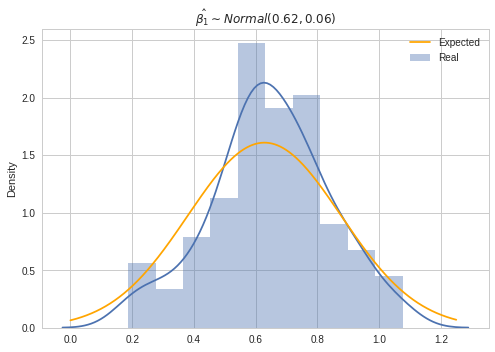

In [0]:
exp_x = np.array(np.linspace(0,1.25,1000))
exp_b1 = norm.pdf(exp_x, loc = real_betas[0], scale = np.sqrt(cov_hat[1,1]))  

sns.distplot(beta_100[:,1], norm_hist = True)
plt.plot(exp_x, np.transpose(exp_b1), color = 'orange')
plt.ylabel('Density')
plt.legend(('Expected', 'Real'), loc='upper right')
plt.title(r"$\hat{\beta_1} \sim Normal (0.62, 0.06)$")
plt.show();

#### Distribution for $\beta_2$

/usr/local/lib/python3.6/dist-packages/matplotlib/axes/_axes.py:6521: MatplotlibDeprecationWarning: 
The 'normed' kwarg was deprecated in Matplotlib 2.1 and will be removed in 3.1. Use 'density' instead.
  alternative="'density'", removal="3.1")


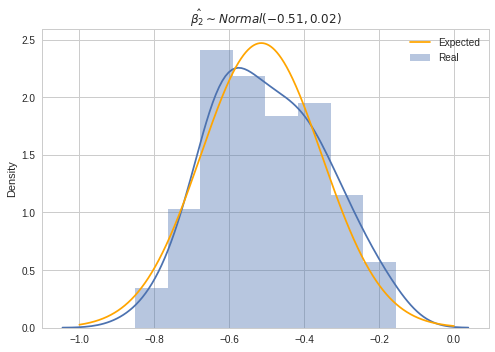

In [0]:
exp_x = np.array(np.linspace(-1,0,1000))
exp_b1 = norm.pdf(exp_x, loc = real_betas[1], scale = np.sqrt(cov_hat[2,2]))  

sns.distplot(beta_100[:,2], norm_hist = True)
plt.plot(exp_x, np.transpose(exp_b1), color = 'orange')
plt.ylabel('Density')
plt.legend(('Expected', 'Real'), loc='upper right')
plt.title(r"$\hat{\beta_2} \sim Normal (-0.51, 0.02)$")
plt.show();

### Interpretation

A change of 1 on the feature k has a change of  $\beta_k$  at the target. When all features are 0, the mean of the target is is  $\beta_0$.

## Regularization

Regularization is an important topic when dealing with multivariate data analysis. In this section we will talk briefly about three important techniques: **LASSO**, **ridge** and **elastic net**. A comprehensive approch of these methods can be found at the section 3.4 on the [Elements of Statistical Learning](https://web.stanford.edu/~hastie/ElemStatLearn/printings/ESLII_print12.pdf) [6]. LASSO and ridge techniques are also called 'L1' or 'Manhattan' and 'L2' regularization, respectively. The Elements of Statistical Learning [7] has a nice visual interpretation of the differences between the two:

![](https://storage.googleapis.com/leandro-random/esl-lasso-ridge.png)

We can see that the blue region defined by LASSO ($|\beta_1|+|\beta_2| \leq t$) on the left and by ridge ($\beta_1^2 + \beta_2^2 \leq t^2$) on the right.




### LASSO

We can rewrite the original optimization problem with the restriction defined by the **l**east **a**bsolute **s**hrinkage and **s**election **o**perator (LASSO).

$$\hat{\boldsymbol{\beta}}^{\text{lasso}} = \underset{\boldsymbol{\beta}}{\text{argmin}}\left\{(\mathbf{Y}-\mathbf{X}\boldsymbol{\beta})^T(\mathbf{Y}-\mathbf{X}\boldsymbol{\beta}) + \lambda\sum_{j=1}^{p}|\beta_j| \right\}$$

or, in an equivalent form:

$$
\begin{align}
\hat{\boldsymbol{\beta}}^{\text{lasso}}  &= \underset{\boldsymbol{\beta}}{\text{argmin}} \quad (\mathbf{Y}-\mathbf{X}\boldsymbol{\beta})^T(\mathbf{Y}-\mathbf{X}\boldsymbol{\beta}), \\
&\quad \text{subject to} \sum_{j=1}^{p}|\beta_j| \leq t.
\end{align}
$$

The parameter $\lambda \geq 0$ controls how much shrinkage you want. If you set $\lambda = 0$ we are back to the standard linear model.



In [0]:
# Cost function for linear regression with lasso regularization
def rss_lasso(beta, x, y, lbd):
  return ((np.transpose(Y - X@beta)@(Y - X@beta)) + lbd*np.sum(np.abs(beta)))

lbd = 0
beta_lasso = minimize(rss_lasso, [0, 0, 0], args = (X,Y,lbd)).x

'Setting lambda to {}, the estimated coefficients beta_0, beta_1 and beta_2 using lasso are {}, {} and {}, respectively'.format(lbd,
                                                                                                                                np.round(beta_lasso[0], 3), 
                                                                                                                                np.round(beta_lasso[1], 3), 
                                                                                                                                np.round(beta_lasso[2], 3))

'Setting lambda to 0, the estimated coefficients beta_0, beta_1 and beta_2 using lasso are 6.546, 0.66 and -0.766, respectively'

When we change $\lambda$ the coefficients start to change.

In [0]:
lbd = 5
beta_lasso = minimize(rss_lasso, [0, 0, 0], args = (X,Y,lbd)).x

'Setting lambda to {}, the estimated coefficients beta_0, beta_1 and beta_2 using lasso are {}, {} and {}, respectively'.format(lbd,
                                                                                                                                np.round(beta_lasso[0], 3), 
                                                                                                                                np.round(beta_lasso[1], 3), 
                                                                                                                                np.round(beta_lasso[2], 3))

'Setting lambda to 5, the estimated coefficients beta_0, beta_1 and beta_2 using lasso are 6.48, 0.654 and -0.753, respectively'

### Ridge

$$\hat{\boldsymbol{\beta}}^{\text{ridge}} = \underset{\boldsymbol{\beta}}{\text{argmin}}\left\{(\mathbf{Y}-\mathbf{X}\boldsymbol{\beta})^T(\mathbf{Y}-\mathbf{X}\boldsymbol{\beta}) + \lambda\sum_{j=1}^{p}\beta_j^2 \right\}$$

or, in an equivalente form:

$$
\begin{align}
\hat{\boldsymbol{\beta}}^{\text{ridge}}  &= \underset{\boldsymbol{\beta}}{\text{argmin}} \quad (\mathbf{Y}-\mathbf{X}\boldsymbol{\beta})^T(\mathbf{Y}-\mathbf{X}\boldsymbol{\beta}), \\
&\quad \text{subject to} \sum_{j=1}^{p}\beta_j^2 \leq t,
\end{align}
$$

Again, if you set $\lambda = 0$ we are back to the standard linear model.

In [0]:
# Cost function for linear regression with ridge regularization
def rss_ridge(beta, x, y, lbd):
  return ((np.transpose(Y - X@beta)@(Y - X@beta)) + lbd*np.sum([b**2 for b in beta]))

lbd = 0
beta_ridge = minimize(rss_ridge, [0, 0, 0], args = (X,Y,lbd)).x

'Setting lambda to {}, the estimated coefficients beta_0, beta_1 and beta_2 using ridge are {}, {} and {}, respectively'.format(lbd,
                                                                                                                                np.round(beta_ridge[0], 3), 
                                                                                                                                np.round(beta_ridge[1], 3), 
                                                                                                                                np.round(beta_ridge[2], 3))

'Setting lambda to 0, the estimated coefficients beta_0, beta_1 and beta_2 using ridge are 6.546, 0.66 and -0.766, respectively'

When we change $\lambda$ the coefficients start to change.

In [0]:
lbd = 5
beta_ridge = minimize(rss_ridge, [0, 0, 0], args = (X,Y,lbd)).x

'Setting lambda to {}, the estimated coefficients beta_0, beta_1 and beta_2 using ridge are {}, {} and {}, respectively'.format(lbd,
                                                                                                                                np.round(beta_ridge[0], 3), 
                                                                                                                                np.round(beta_ridge[1], 3), 
                                                                                                                                np.round(beta_ridge[2], 3))

'Setting lambda to 5, the estimated coefficients beta_0, beta_1 and beta_2 using ridge are 5.847, 0.68 and -0.648, respectively'

### Elastic Net

Before presenting the Elastic Net, consider the generalization of lasso and ridge:

$$\hat{\boldsymbol{\beta}} = \underset{\boldsymbol{\beta}}{\text{argmin}}\left\{(\mathbf{Y}-\mathbf{X}\boldsymbol{\beta})^T(\mathbf{Y}-\mathbf{X}\boldsymbol{\beta}) + \lambda\sum_{j=1}^{p}|\beta_j|^q \right\}$$

for $q \geq 0$. Setting different values for q, we define different restrictions for the optimization problem. When choosing values of $q \in (1,2)$ we are making a compromise between lasso and ridge regression [3]. One problem with this approach is that, except for $q = 1$, the function is differentiable at 0, loosing LASSO's ability for feature selection. In this context, the elastic net is proposed as a different regularization technique that keeps lasso's ability for feature selection and shrinks coefficients of correlated features like ridge.

$$\hat{\boldsymbol{\beta}}^{\text{elastic net}} = \underset{\boldsymbol{\beta}}{\text{argmin}}\left\{(\mathbf{Y}-\mathbf{X}\boldsymbol{\beta})^T(\mathbf{Y}-\mathbf{X}\boldsymbol{\beta}) + \lambda\sum_{j=1}^{p}(\alpha\beta_j^2 + (1-\alpha)|\beta_j|) \right\}$$

for $\alpha \in (0,1)$. When $\alpha = 0$ the elastic net turns into lasso, and when $\alpha = 1$ into ridge.





In [0]:
# Cost function for linear regression with elastic net regularization
def rss_elastic_net(beta, x, y, lbd, alpha):
  return ((np.transpose(Y - X@beta)@(Y - X@beta)) + lbd*np.sum(alpha*np.array([b**2 for b in beta]) + (1-alpha)*np.abs(beta)))

lbd = 5
alpha = 1
beta_elastic = minimize(rss_elastic_net, [0, 0, 0], args = (X, Y, lbd, alpha)).x

'Setting lambda to {} and alpha to {}, the estimated coefficients beta_0, beta_1 and beta_2 using elastic net are {}, {} and {}, respectively'.format(lbd, alpha,
                                                                                                                                                      np.round(beta_ridge[0], 3), 
                                                                                                                                                      np.round(beta_ridge[1], 3), 
                                                                                                                                                      np.round(beta_ridge[2], 3))

'Setting lambda to 5 and alpha to 1, the estimated coefficients beta_0, beta_1 and beta_2 using elastic net are 5.847, 0.68 and -0.648, respectively'

## References

[1] Luis Serrano. (n.d.). A Friendly Introduction to Linear Regression. Retrieved from https://www.youtube.com/watch?v=wYPUhge9w5c

[2] Trekhleb, O. (2019). 🤖 Python examples of popular machine learning algorithms with interactive Jupyter demos and math being explained: trekhleb/homemade-machine-learning. Jupyter Notebook. Retrieved from https://github.com/trekhleb/homemade-machine-learning (Original work published 2018)

[3] zotroneneis. (2019). Plain python implementations of basic machine learning algorithms: zotroneneis/machine_learning_basics. Jupyter Notebook. Retrieved from https://github.com/zotroneneis/machine_learning_basics (Original work published 2018)

[4] Is there a way to use the covariance matrix to find coefficients for multiple regression? (n.d.). Retrieved January 24, 2019, from https://stats.stackexchange.com/questions/107597/is-there-a-way-to-use-the-covariance-matrix-to-find-coefficients-for-multiple-re

[5] Costa, M. A. (2019). Tópicos em ciência dos dados: Introdução aos modelos paramétricos e seus aplicações utilizando o R. Bonecker.

[6] Hastie, T., Tibshirani, R., & Friedman, J. H. (2009). The elements of statistical learning: data mining, inference, and prediction (2nd ed). New York, NY: Springer.
